In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

In [2]:
# automatically reload all modules before executing new code. The captures changes in
# local packages.
%load_ext autoreload
%autoreload 2

In [14]:
%%writefile ../src/deep_agents_from_scratch/research_tools.py
"""Research Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""
import os
from datetime import datetime
import uuid, base64

import httpx
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, ToolMessage
from langchain.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from markdownify import markdownify
from pydantic import BaseModel, Field
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

from deep_agents_from_scratch.prompts import SUMMARIZE_WEB_SEARCH
from deep_agents_from_scratch.state import DeepAgentState

# summarization model
summarization_model = init_chat_model(model="openai:gpt-4o-mini")
tavily_client = TavilyClient()

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    filename: str = Field(description="Name of the file to store.")
    summary: str = Field(description="Key learnings from the webpage.")

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def run_tavily_search(
    search_query: str,
    max_results: int = 1,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = True,
) -> dict:
    """Perform search using Tavily API for a single query.
    
    Args:
        search_query: Search query to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content
        
    Returns:
        Search results dictionary
    """
    
    return tavily_client.search(
        search_query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

def summarize_webpage_content(webpage_content: str) -> Summary:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Summary object with filename and summary
    """
    
    try:
        # set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # generate summary
        summary_and_filename = structured_model.invoke([
            HumanMessage(content=SUMMARIZE_WEB_SEARCH.format(
                webpage_content=webpage_content,
                date=get_today_str()
            ))
        ])
        
        return summary_and_filename
    except Exception:
        # return a basic summary object on failure
        return Summary(
            filename="search_result.md",
            summary=webpage_content[:1000] + "..." if len(webpagecontent) > 1000 else webpage_content
        )
        
def process_search_results(results: dict) -> list[dict]:
    """Process search results by summarizing content where available.
    
    Args:
        results: Tavily search results dictionary
        
    Returns:
        List of processed results  with summaries
    """
    
    processed_results = []
    
    # create a client for HTTP requests with timeout
    HTTPX_CLIENT = httpx.Client(timeout=30.0) # add 30 second timeout
    
    for result in results.get("results", []):
        # get url
        url = result["url"]
        
        # read url with timeout and error handling
        try:
            response = HTTPX_CLIENT.get(url)
            
            if response.status_code == 200:
                # convert HTML to markdown
                raw_content = markdownify(response.text)
                summary_obj = summarize_webpage_content(raw_content)
            else:
                # use tavily's generated summary
                raw_content = result.get("raw_content", "")
                summary_obj = Summary(
                    filename="URL_error.md",
                    summary=result.get("content", "Error reading URL; try another search.")
                )
        except (httpx.TimeoutException, httpx.RequestError) as e:
            # handle timeout of connection errors gracefully
            raw_content = result.get("raw_content", "")
            summary_obj = Summary(
                filename="connection_error.md",
                summary=result.get("content", f"Could not fetch URL (timeout/connection error). Try another search.")
            )

        # uniquify file names
        uid = base64.urlsafe_b64encode(uuid.uuid4().bytes).rstrip(b"=").decode("ascii")[:8]
        name, ext = os.path.splitext(summary_obj.filename)
        summary_obj.filename = f"{name}_{uid}{ext}"
        
        processed_results.append({
            "url": result["url"],
            "title": result["title"],
            "summary": summary_obj.summary,
            "filename": summary_obj.filename,
            "raw_content": raw_content 
        })

    return processed_results

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general" 
) -> Command:
    """Search web and save detailed results to files while returning minimal context.
    
    Performs web search and saves full content to files for context offloading.
    Returns only essential information to help the agent decide on next steps.
    
    Args:
        query: Search query to execute
        state: Injected agent state for file storage
        tool_call_id: Injected tool call identifier
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')
        
    Returns:
        Command that saves full results to files and provides minimal summary
    """
    
    # execute search
    search_results = run_tavily_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True
    )

    # process and summarize results
    processed_results = process_search_results(search_results)
    
    # save each result to a file and prepare summary
    files = state.get("files", {})
    saved_files = []
    summaries = []
    
    for i, result in enumerate(processed_results):
        # use the AI-generated filename from summarization
        filename = result["filename"]
        
        # create file content with full details
        file_content = f"""# Search Result: {result['title']}
        **URL:** {result['url']}
        **Query:** {query}
        **Date:** {get_today_str()}
        
        ## Summary
        {result['summary']}
        
        ## Raw Content
        {result['raw_content'] if result['raw_content'] else 'No raw content available'}
        """

        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"- {filename}: {result['summary']}...")
        
    # create minimal summary for tool message - focus on what was collected
    summary_text = f"""🔍 Found {len(processed_results)} result(s) for '{query}':
    
    {chr(10).join(summaries)}
    
    Files: {', '.join(saved_files)}
    Use read_file() to access full details when needed.
    """
    
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(summary_text, tool_call_id=tool_call_id)
            ]
        }
    )

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.
    
    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.
    
    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?
    
    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?
    
    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and
                    next steps
    
    Returns:
        Confirmation that reflection was recorded for decision-making
    """

Overwriting ../src/deep_agents_from_scratch/research_tools.py


In [15]:
from datetime import datetime

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from utils import show_prompt, stream_agent

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.prompts import (
    FILE_USAGE_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_USAGE_INSTRUCTIONS,
    TODO_USAGE_INSTRUCTIONS
)
from deep_agents_from_scratch.research_tools import tavily_search, think_tool, get_today_str
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool
from deep_agents_from_scratch.todo_tools import write_todos, read_todos


# create agent using create_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-20250514", temperature=0.0)

# limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# tools
sub_agent_tools = [tavily_search, think_tool]
built_in_tools = [ls, read_file, write_file, write_todos, read_todos, think_tool]

# create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": ["tavily_search", "think_tool"]
}

# create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools,
    [research_sub_agent],
    model,
    DeepAgentState
)

delegation_tools = [task_tool]
all_tools = sub_agent_tools + built_in_tools + delegation_tools # search available to main agent for trivial cases

# build prompt
SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%a %b %-d, %Y")
)

In [16]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭─────────────────────────────────── Prompt ───────────────────────────────────╮
│                                                                              │
│  You are a research assistant conducting research on the user's input        │
│  topic. For context, today's date is {date}.                                 │
│                                                                              │
│  <Task>                                                                      │
│  Your job is to use tools to gather information about the user's input       │
│  topic.                                                                      │
│  You can use any of the tools provided to you to find resources that can     │
│  help answer the research question. You can call these tools in series or    │
│  in parallel, your research is conducted in a tool-calling loop.             │
│  </Task>                                                                     │
│                           

In [17]:
INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)

show_prompt(INSTRUCTIONS)

╭─────────────────────────────────── Prompt ───────────────────────────────────╮
│                                                                              │
│  # TODO MANAGEMENT                                                           │
│  Based upon the user's request:                                              │
│  1. Use the write_todos tool to create TODO at the start of a user request,  │
│  per the tool description.                                                   │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in     │
│  order to remind yourself of the plan.                                       │
│  3. Reflect on what you've done and the TODO.                                │
│  4. Mark you task as completed, and proceed to the next TODO.                │
│  5. Continue this process until you have completed all TODOs.                │
│                                                                              │
│  IMPORTANT: Always create 

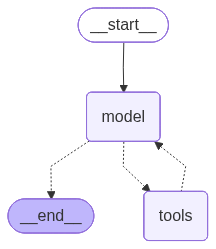

In [18]:
# create agent
agent = create_agent(
    model,
    all_tools,
    system_prompt=INSTRUCTIONS,
    state_schema=DeepAgentState
)

# show the agent
agent

In [13]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP)."
            }
        ]
    }
)

format_messages(result["messages"])

NameError: name 'sumaries' is not defined